In [1]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, Graphs
import pandas as pd
train_info = GraphsTraining()

### Load JAX results

### Load Pyomo results

In [7]:
results_pyomo = load_all_pickles("results/study_ho_reg/pyomo_ho_241225", recursive=False)
pyomo_df = Results.flatten_convergence_data(results_pyomo, key_list=["system", "reg", "tol"], model_type="pyomo")

# results_reg_norm_df = results_reg_norm_df.dropna()
# results_reg_norm_df["n_neurons"] = results_reg_norm_df["system"].apply(lambda x: x[1])

Loaded results/study_ho_reg/pyomo_ho_241225/1169419491_2025-12-24_17-10.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1333561404_2025-12-24_12-07.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1385356387_2025-12-24_17-09.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1755179491_2025-12-24_17-08.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2024901110_2025-12-24_11-24.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2100520546_2025-12-24_11-41.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2513813645_2025-12-24_12-34.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2673879830_2025-12-24_13-54.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/290969297_2025-12-24_14-39.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2939113681_2025-12-24_11-18.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3153811625_2025-12-24_14-22.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3212649863_2025-12-24_13-24.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3223672450_2025-12-24_15-04.pkl
Loaded result

In [8]:
pyomo_df.head(1)

,system,reg,tol,time_elapsed,direct_model_pred,odeint_pred,odeint_pred_test,mse_train,mse_test,mse_train_coll,mse_test_coll,termination,seed
0,"(2, 32, 2)",0.1,0.000001,3.756586,"[[5.270032838050456e-25, 0.0006127630303125921...","[[0.0, 1.0], [0.0006127631, 0.9999918], [0.002...","[[0.70709795, -0.004968702], [0.707104, -0.005...",0.000104,0.000345,0.000129,0.000394,optimal,1.169419e+09


In [9]:
pyomo_train = Results.prep_for_boxplots(pyomo_df,  'reg',  'mse_train_coll')

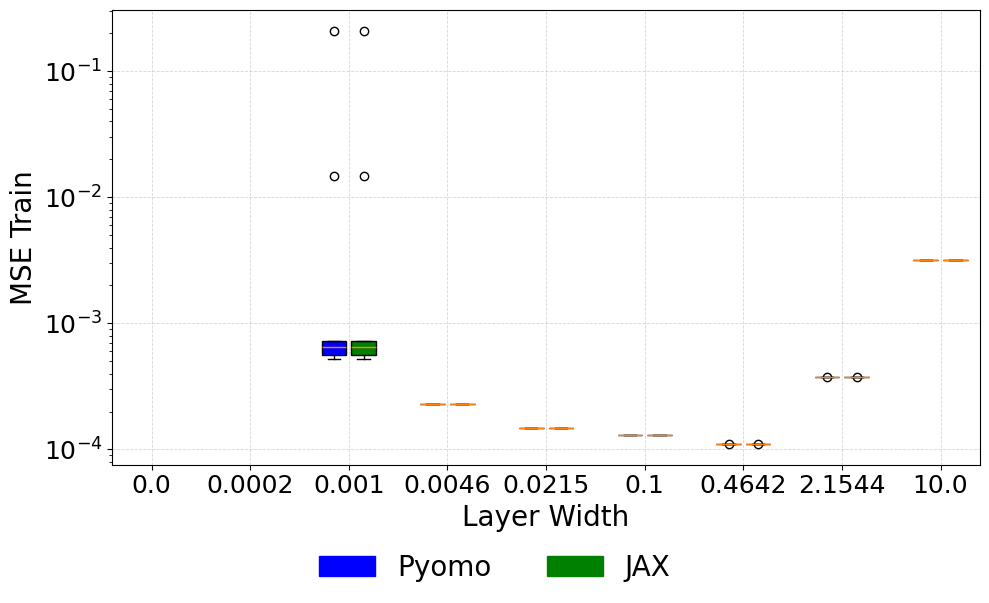

<Axes: xlabel='Layer Width', ylabel='MSE Train'>

In [10]:
Graphs.plot_boxplots_custom(pyomo_train['mse_train_coll'], pyomo_train['mse_train_coll'], pyomo_train.x_labels, 
            '',     
              'MSE Train', color_labels=["Pyomo", "JAX"],
              x_label = "Layer Width",
              figsize=(10, 6),
              label_fontsize=20,
              tick_fontsize=18,
              legend_fontsize=20,
              title_fontsize=20,
              legend_bbox_y=-0.02,
              legend_ncol=2,
              y_log = True
              )

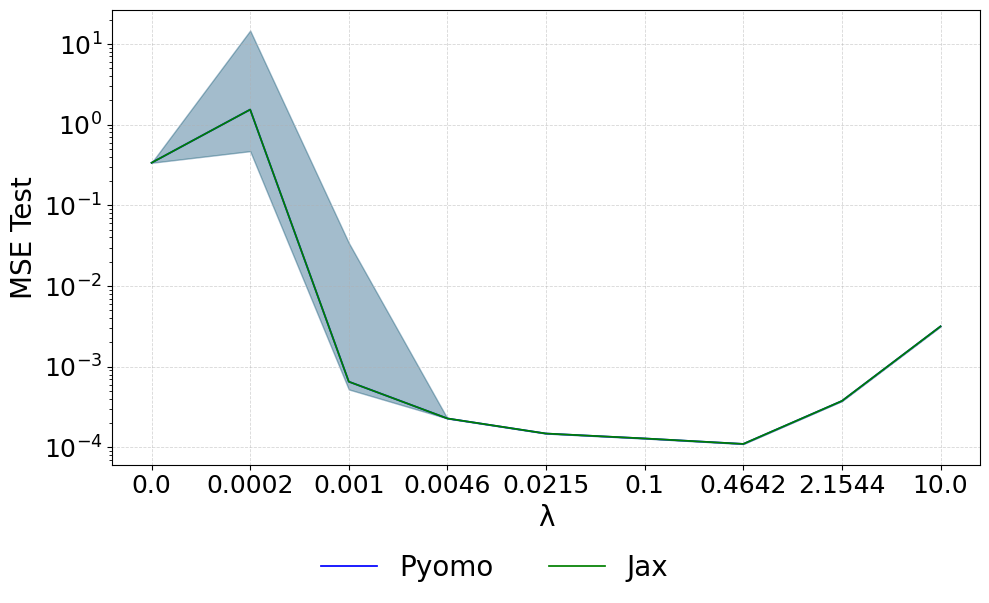

<Axes: xlabel='λ', ylabel='MSE Test'>

In [11]:
Graphs.plot_lines_ci_from_lists(
    pyomo_train['mse_train_coll'],
    pyomo_train['mse_train_coll'],
    pyomo_train.x_labels,
    title="",
    ylabel="MSE Test",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(10,90),
    alpha_band=0.2,
    line_width=1.25,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
)
